# Random Forest Classification on PneumoniaMNIST

### High-Level Dataset Overview — PneumoniaMNIST

What it is:
A binary image classification dataset derived from pediatric chest X-rays.

Task:
Classify images as:
- 0 = Normal
- 1 = Pneumonia

Size:
- Train: 4,708
- Validation: 524
- Test: 624
- Total 5,856 images.

Image format:
- Gray-scale
- 28×28 pixels (MNIST-like)

No clinical preprocessing required.

This dataset is ideal for demonstrating how classic machine learning methods (like Random Forest).

### Step 1 — Install & Import Libraries

In [1]:
pip install medmnist

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from medmnist import PneumoniaMNIST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### 2: Let's load the dataset

In [3]:
train_ds = PneumoniaMNIST(split='train', download=True)
val_ds   = PneumoniaMNIST(split='val', download=True)
test_ds  = PneumoniaMNIST(split='test', download=True)

In [4]:
train_ds.info

{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

### 3. Visualize Examples 

In [5]:
train_ds[0]

(<PIL.Image.Image image mode=L size=28x28>, array([1]))

In [21]:
#example visual
train_ds[0][0]

In [7]:
train_ds[0][1]

array([1])

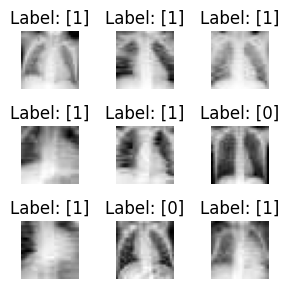

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(3,3))
for i, ax in enumerate(axes.flatten()):
    image, label = train_ds[i]        # unpack
    image_np = np.array(image)        # convert to NumPy array
    ax.imshow(image_np, cmap='gray')  # fixed
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 4. Prepare the data for Random Forest



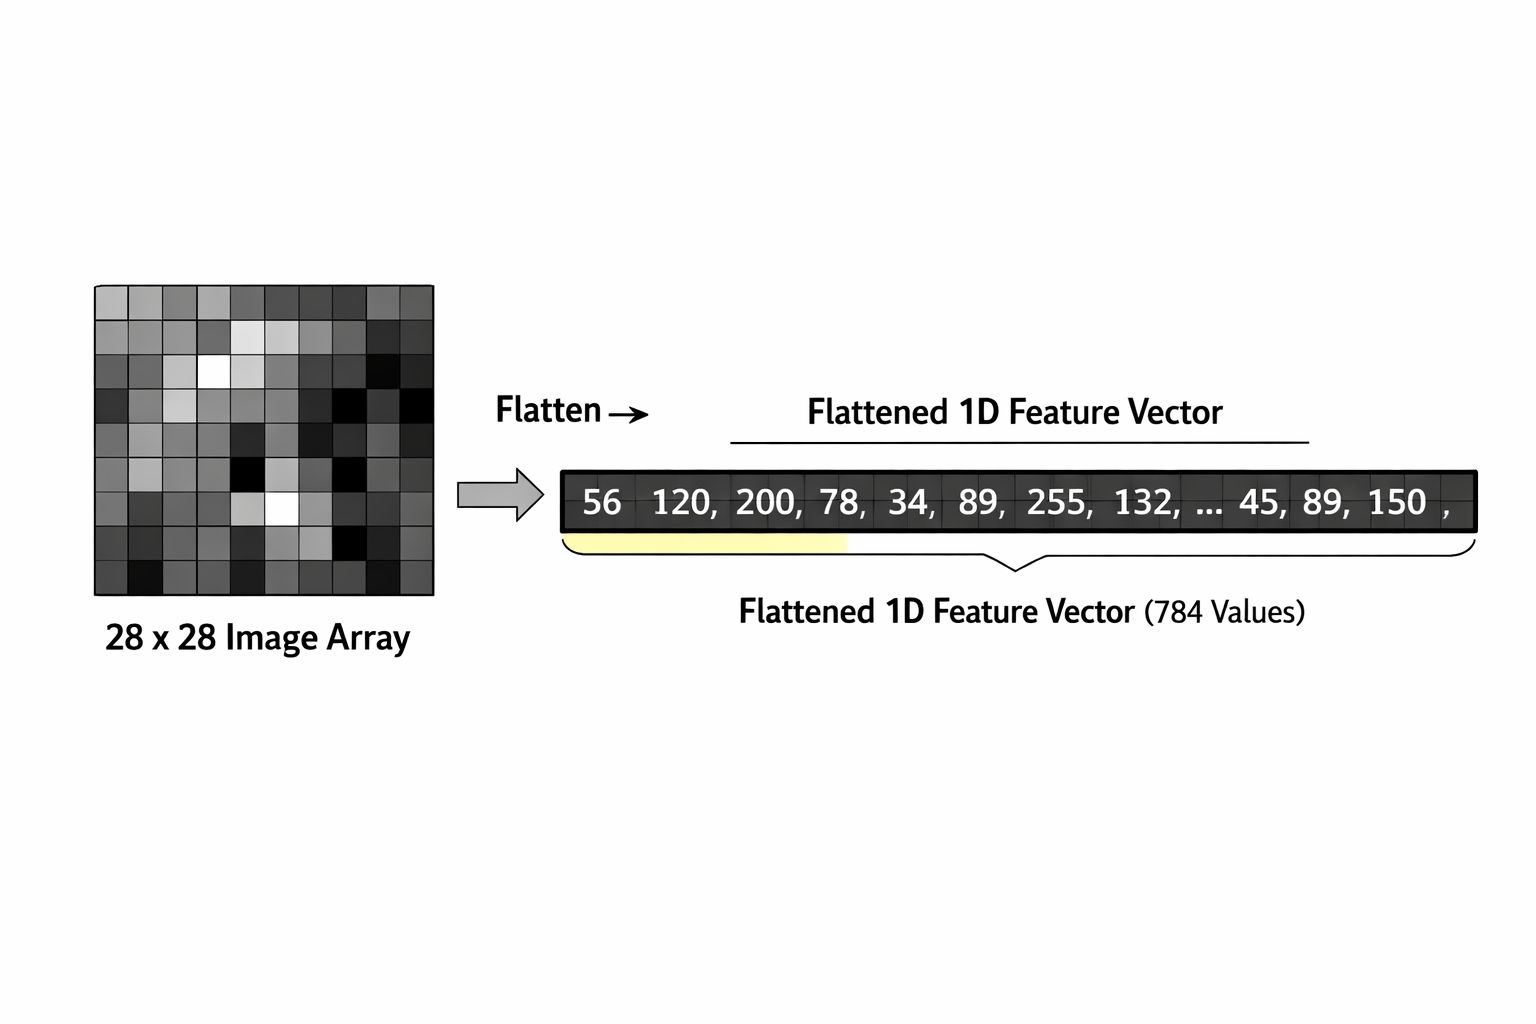

In [9]:
import numpy as np

def flatten_ds(ds):
    images = []
    labels = []
    
    for item in ds:
        img, label = item       # unpack (PIL Image, int)
        img_np = np.array(img)  # convert to NumPy array
        img_flat = img_np.flatten()  # now flatten works
        images.append(img_flat)
        labels.append(label)
    
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

X_train, y_train = flatten_ds(train_ds)
X_val,   y_val   = flatten_ds(val_ds)
X_test,  y_test  = flatten_ds(test_ds)

### 5 — Train a Random Forest Classifier

This trains 100 decision trees on random subsets of the flattened images.


In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

/Users/josoga2/Documents/wale_docs/phd/HB/py/hb_ml/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 6- Evaluate Performance

In [11]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8493589743589743
              precision    recall  f1-score   support

           0       0.94      0.64      0.76       234
           1       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.83       624
weighted avg       0.86      0.85      0.84       624



### Step 7 — Confusion Matrix

The confusion matrix highlights real vs predicted counts:

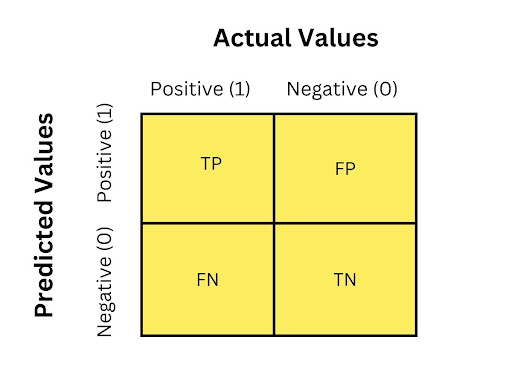

[[149  85]
 [  9 381]]


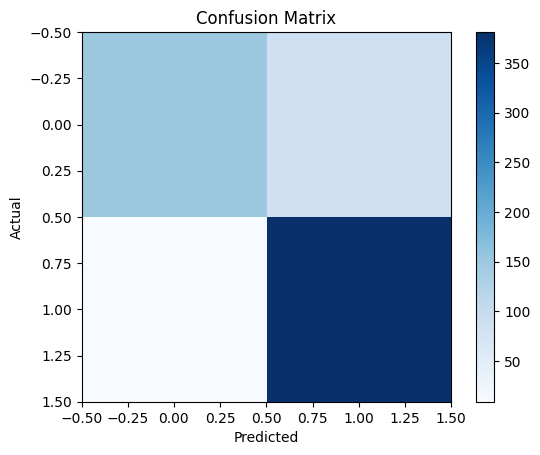

In [24]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Feature Importance

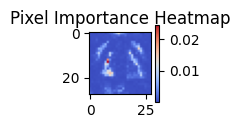

In [13]:
importances = rf.feature_importances_
importance_map = importances.reshape(28, 28) #collapse it back to the image

plt.figure(figsize=(1,1))
plt.imshow(importance_map, cmap='coolwarm')
plt.colorbar()
plt.title("Pixel Importance Heatmap")
plt.show()